# 분석 결과 벡터 DB 연동 및 모델 API 설계/배포

**이미지 지식화** 실습 — Qwen3-VL 분석 결과를 ChromaDB에 저장하고, FastAPI로 서비스화합니다.

> **선행 학습**: `02_conveyor_belt_visual_rag.ipynb`로 프레임·센서·ChromaDB 인덱스를 먼저 구축하고 실행.

## 전체 흐름

```
02 노트북 (프레임 + 센서 + 이미지 벡터 DB)
       ↓
이미지·센서 메타정보 연계 (frame 키 조인 · ChromaDB 검증)
       ↓
Qwen3-VL 분석 결과 생성
       ↓
분석 텍스트 → SigLIP2 임베딩 → ChromaDB (analysis 컬렉션)
       ↓
과거 분석 결과 벡터 검색
       ↓
FastAPI REST API 설계 (/search, /analyze, /analysis/search ...)
       ↓
API 배포·호출 실습 (requests)
```

| 구분 | 컬렉션 | 저장 내용 |
|------|--------|----------|
| **이미지 DB** | `conveyor_siglip2` | 프레임 임베딩 + 센서 메타 |
| **분석 DB** | `conveyor_analysis_results` | Qwen 분석 텍스트 임베딩 + 질의·프레임 |

### 왜 분석 결과도 벡터 DB에?

JSON 파일(`history.json`)만 쓰면 **키워드 일치** 검색만 가능합니다.
분석 문장을 벡터화하면 **"진동 이상"**, **"과열 징후"** 처럼 의미가 비슷한 과거 분석을 찾을 수 있습니다.


### 모듈 소스 참조

노트북에서 `import` 하는 Python 모듈·API·데이터 경로는 프로젝트 루트 문서를 참고하세요.

📄 **[00_모듈_참조.md](00_모듈_참조.md)** — 경로별 파일 목록 + 기능 요약

| 노트북에서 직접 import | 경로 |
|------------------------|------|
| `metadata_link` | `conveyor_analyze/conveyor_rag/metadata_link.py` |
| `plot_utils` | `conveyor_analyze/conveyor_rag/plot_utils.py` |
| FastAPI (HTTP 호출) | `conveyor_analyze/api/main.py` |

## 0. 환경 설정

| 기술 | 역할 |
|------|------|
| **ChromaDB** | 이미지·분석 결과 두 종류의 벡터 컬렉션 관리 |
| **sensor.csv** | 프레임별 temp/rpm/vibration/status — Chroma 메타와 1:1 연계 |
| **metadata_link** | 이미지·센서·ChromaDB 메타 조인·검증 유틸 |
| **SigLIP2** | 분석 텍스트를 검색 가능한 벡터로 변환 |
| **FastAPI** | REST API — 검색·분석·센서·이력 엔드포인트 |
| **requests** | 노트북에서 API 호출 테스트 |
| **uvicorn** | FastAPI ASGI 서버 (배포) |


**사전 준비**
<br>
Conveyor_Belt_Sample.zip 파일을 현재 경로에 다운받아 놓는다<br>
conveyor_analyze.zip 파일을 다운 받아 압축 해제해놓는다 <br>
만일 02_conveyor_belt_visual_rag.ipynb 소스를 실행하지 않은경우
data.zip을 다운 받아 압축 해제해놓는다


In [1]:
# !pip install -r conveyor_analyze/requirements.txt
# 선행: 02 노트북 완료 + Conveyor_Belt_Sample.zip

# 이 소스는 Colab에서 실행불가하다!!
# 별도 터미널에서 띄우는 백그라운드 FastAPI 서버(127.0.0.1:8000)에 의존하는데,
# Colab은 그 구조를 기본으로 지원하지 않음 

In [2]:
import json
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import chromadb
import pandas as pd
import requests
import torch
from IPython.display import display, Markdown
from transformers import AutoModel, AutoProcessor

# --- 경로 ---
# 프로젝트 루트(09_Visual_RAG)에서 노트북 실행 시 Path(".") 기준
ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data" / "conveyor"       # 02 노트북 산출물 루트
CHROMA_DIR = DATA_DIR / "chroma_db"         # ChromaDB 디스크 저장
FRAMES_DIR = DATA_DIR / "frames"            # frame0001.jpg ...
SENSOR_CSV = DATA_DIR / "sensor.csv"        # 프레임별 가상 센서
CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"  # FastAPI·metadata_link 패키지

# conveyor_analyze 모듈 import
sys.path.insert(0, str(CONVEYOR_ANALYZE))

from conveyor_rag.plot_utils import setup_korean_matplotlib

_korean_font = setup_korean_matplotlib()

FRAME_COLLECTION = "conveyor_siglip2"           # 이미지 벡터 컬렉션
ANALYSIS_COLLECTION = "conveyor_analysis_results"  # 분석 텍스트 벡터 컬렉션
SIGLIP2_MODEL_ID = "google/siglip2-so400m-patch14-384"
API_BASE = "http://127.0.0.1:8000"  # run_api.py 기본 포트

device = "cuda" if torch.cuda.is_available() else "cpu"

# 02 노트북 산출물 확인
if not CHROMA_DIR.exists() or not list((DATA_DIR / "frames").glob("frame*.jpg")):
    raise FileNotFoundError(
        "02 노트북을 먼저 실행해 data/conveyor/frames 와 chroma_db 를 생성하세요."
    )

print(f"ROOT: {ROOT}")
print(f"Device: {device}")
print(f"ChromaDB: {CHROMA_DIR}")
print(f"conveyor_analyze: {CONVEYOR_ANALYZE.exists()}")
print(f"matplotlib 한글 폰트: {_korean_font or '미설정'}")


def get_chroma_client():
    """항상 최신 ChromaDB 클라이언트 (API/파이프라인 재실행 후 stale 방지)."""
    # collection 객체를 오래 들고 있으면 NotFoundError 발생 가능 → 매번 새 클라이언트
    return chromadb.PersistentClient(path=str(CHROMA_DIR))


def get_collection(name: str, create: bool = False):
    """컬렉션을 이름으로 조회. 오래된 collection 객체 참조 오류 방지."""
    client = get_chroma_client()
    try:
        return client.get_collection(name)
    except Exception:
        if not create:
            raise FileNotFoundError(
                f"ChromaDB 컬렉션 '{name}' 없음. "
                "02 노트북 또는 conveyor_analyze/scripts/run_pipeline.py 를 먼저 실행하세요."
            )
        return client.get_or_create_collection(
            name=name,
            metadata={"hnsw:space": "cosine"},  # 코사인 유사도 = 1 - distance
        )


ROOT: C:\MyCursorLab\09_Visual_RAG
Device: cuda
ChromaDB: C:\MyCursorLab\09_Visual_RAG\data\conveyor\chroma_db
conveyor_analyze: True
matplotlib 한글 폰트: Malgun Gothic


## 1. 기존 이미지 벡터 DB 확인

02 노트북에서 구축한 **프레임 컬렉션**을 확인합니다.

| 항목 | 설명 |
|------|------|
| `conveyor_siglip2` | 프레임 이미지 SigLIP2 임베딩 |
| metadata | frame, temp, rpm, vibration, status 등 센서 연계 |


In [3]:
frame_collection = get_collection(FRAME_COLLECTION)
print(f"이미지 벡터 수: {frame_collection.count()}")

sample = frame_collection.peek(limit=3)
display(pd.DataFrame(sample["metadatas"]))


이미지 벡터 수: 20


,vibration,speed,status,rpm,local_path,temp,current,frame,machine
0,0.08,0.95,Normal,1150,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,38.2,2.9,frame0001.jpg,M01
1,0.10,0.95,Normal,1170,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,39.1,3.0,frame0002.jpg,M01
2,0.31,0.96,Warning,1230,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...,45.3,3.8,frame0003.jpg,M01


## 2. 이미지·센서 메타정보 연계

Visual RAG에서 **이미지(프레임)** 와 **수치 센서**를 `frame` 키로 1:1 연결합니다.

```
frame0003.jpg  ←→  sensor.csv 행  ←→  ChromaDB metadata
     │                    │                    │
  이미지 파일          temp/rpm/...         검색 결과에 즉시 노출
```

| 연계 단계 | 저장소 | 키 | 실습 내용 |
|-----------|--------|-----|----------|
| **1. 조인** | `frames/` + `sensor.csv` | `frame` | 프레임별 센서 테이블 생성 |
| **2. 인덱싱** | ChromaDB `conveyor_siglip2` | `frame` | 임베딩 + 센서 메타 동시 저장 |
| **3. 검증** | Chroma vs CSV | `frame` | 값 일치 여부 확인 |
| **4. 검색** | `/search` 응답 | `metadata` + `sensor` | 텍스트 검색 후 센서 수치 병합 |

> `conveyor_rag/metadata_link.py` — 파이프라인·API·노트북이 공유하는 연계 유틸리티

In [4]:
from conveyor_rag.metadata_link import (
    build_frame_sensor_table,
    build_chroma_metadata_for_frame,
    verify_chroma_sensor_sync,
    enrich_hits_with_sensor,
    filter_hits_by_status,
    SENSOR_META_KEYS,
)

# 2-1. 프레임 ↔ sensor.csv 조인 테이블
linked_df = build_frame_sensor_table(FRAMES_DIR, SENSOR_CSV)
print(f"연계 프레임: {len(linked_df)}장")
display(linked_df[SENSOR_META_KEYS + ["image_path"]])

# 2-2. ChromaDB 저장 메타 예시 (store.py 와 동일 규칙)
sample_frame = sorted(FRAMES_DIR.glob("frame*.jpg"))[2]
sample_meta = build_chroma_metadata_for_frame(sample_frame)
print(f"\n[ChromaDB 메타 예시] {sample_frame.name}")
print(json.dumps(sample_meta, indent=2, ensure_ascii=False))

# 2-3. ChromaDB 메타 ↔ sensor.csv 동기화 검증
sync_report = verify_chroma_sensor_sync(get_collection(FRAME_COLLECTION), SENSOR_CSV)
matched = int(sync_report["match"].sum())
print(f"\n동기화 검증: {matched}/{len(sync_report)} 일치")
display(sync_report)

연계 프레임: 20장


,frame,machine,temp,rpm,vibration,current,speed,status,image_path
0,frame0001.jpg,M01,38.2,1150,0.08,2.9,0.95,Normal,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
1,frame0002.jpg,M01,39.1,1170,0.10,3.0,0.95,Normal,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
2,frame0003.jpg,M01,45.3,1230,0.31,3.8,0.96,Warning,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
3,frame0004.jpg,M01,48.8,1260,0.45,4.1,0.98,Fault,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
4,frame0005.jpg,M01,49.2,1262,0.47,4.1,0.98,Fault,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
5,frame0006.jpg,M01,49.6,1265,0.48,4.2,0.98,Fault,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
6,frame0007.jpg,M01,50.0,1267,0.50,4.2,0.98,Fault,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
7,frame0008.jpg,M01,50.5,1270,0.52,4.3,0.99,Fault,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
8,frame0009.jpg,M01,50.9,1272,0.53,4.3,0.99,Warning,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...
9,frame0010.jpg,M01,51.3,1275,0.55,4.3,0.99,Warning,C:\MyCursorLab\09_Visual_RAG\data\conveyor\fra...



[ChromaDB 메타 예시] frame0003.jpg
{
  "frame": "frame0003.jpg",
  "local_path": "C:\\MyCursorLab\\09_Visual_RAG\\data\\conveyor\\frames\\frame0003.jpg",
  "machine": "M01",
  "temp": 45.3,
  "rpm": 1230,
  "vibration": 0.31,
  "current": 3.8,
  "speed": 0.96,
  "status": "Warning"
}

동기화 검증: 20/20 일치


,frame,match,mismatch_fields
0,frame0001.jpg,True,
1,frame0002.jpg,True,
2,frame0003.jpg,True,
3,frame0004.jpg,True,
4,frame0005.jpg,True,
5,frame0006.jpg,True,
6,frame0007.jpg,True,
7,frame0008.jpg,True,
8,frame0009.jpg,True,
9,frame0010.jpg,True,


Fault 프레임: 5장


,frame,temp,rpm,vibration,current,status
0,frame0004.jpg,48.8,1260,0.45,4.1,Fault
1,frame0005.jpg,49.2,1262,0.47,4.1,Fault
2,frame0006.jpg,49.6,1265,0.48,4.2,Fault
3,frame0007.jpg,50.0,1267,0.50,4.2,Fault
4,frame0008.jpg,50.5,1270,0.52,4.3,Fault


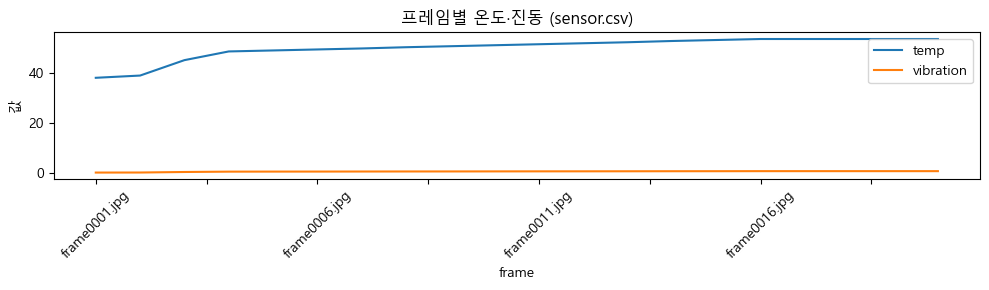

In [5]:
import matplotlib.pyplot as plt

setup_korean_matplotlib()  # 한글 제목·축 깨짐 방지

# 2-4. 메타데이터 status 로 Fault 프레임 추출 (ChromaDB where 필터)
collection = get_collection(FRAME_COLLECTION)
fault_result = collection.get(where={"status": "Fault"}, include=["metadatas"])
fault_df = pd.DataFrame(fault_result["metadatas"])
print(f"Fault 프레임: {len(fault_df)}장")
display(fault_df[["frame", "temp", "rpm", "vibration", "current", "status"]])

# 2-5. 센서 시계열 시각화 (프레임 순)
plot_df = linked_df.set_index("frame")[["temp", "vibration"]]
plot_df.plot(figsize=(10, 3), rot=45)
plt.title("프레임별 온도·진동 (sensor.csv)")
plt.ylabel("값")
plt.tight_layout()
plt.show()

In [6]:
# 2-6. 검색 hit + 센서 메타 enrichment (metadata_link.enrich_hits_with_sensor)
sim_hits = [
    {"similarity": 0.95 - i * 0.05, "metadata": m}
    for i, m in enumerate(fault_result["metadatas"][:3])
]
if not sim_hits:
    fp = FRAMES_DIR / linked_df.iloc[0]["frame"]
    sim_hits = [{"similarity": 0.9, "metadata": build_chroma_metadata_for_frame(fp)}]

enriched = enrich_hits_with_sensor(sim_hits, SENSOR_CSV)
fault_only = filter_hits_by_status(enriched, "Fault")

rows = []
for h in enriched:
    meta = h["metadata"]
    sensor = h.get("sensor", meta)
    rows.append({
        "frame": meta.get("frame"),
        "similarity": round(h.get("similarity", 0), 3),
        "status": sensor.get("status"),
        "temp": sensor.get("temp"),
        "vibration": sensor.get("vibration"),
    })

print("[검색 + 센서 연계 결과] (로컬 시뮬레이션)")
display(pd.DataFrame(rows))
print(f"Fault 필터: {len(fault_only)}건")
print("→ API 연동은 섹션 5에서 /search, /metadata/verify 를 호출합니다.")

[검색 + 센서 연계 결과] (로컬 시뮬레이션)


,frame,similarity,status,temp,vibration
0,frame0004.jpg,0.95,Fault,48.8,0.45
1,frame0005.jpg,0.90,Fault,49.2,0.47
2,frame0006.jpg,0.85,Fault,49.6,0.48


Fault 필터: 3건
→ API 연동은 섹션 5에서 /search, /metadata/verify 를 호출합니다.


## 3. 분석 결과 → 벡터 DB 연동

Qwen3-VL이 생성한 **분석 텍스트**를 SigLIP2로 임베딩하여 별도 ChromaDB 컬렉션에 저장합니다.

```
질의(query) + 분석(analysis)
       ↓
SigLIP2 text embedding
       ↓
ChromaDB: conveyor_analysis_results
       ↓
"과열 관련 과거 분석 찾기" → 벡터 유사도 검색
```

실습에서는 GPU 부담을 줄이기 위해 **샘플 분석 결과**를 먼저 저장합니다.
(API `/analyze` 실행 시에도 동일 로직이 자동 적용됩니다.)


In [7]:
class SigLIP2TextEncoder:
    """분석 텍스트 임베딩용 경량 래퍼."""

    def __init__(self):
        # 이미지 인코더와 동일 모델 — 텍스트·이미지가 같은 벡터 공간
        dtype = torch.float16 if device == "cuda" else torch.float32
        self.model = AutoModel.from_pretrained(SIGLIP2_MODEL_ID, torch_dtype=dtype).to(device).eval()
        self.processor = AutoProcessor.from_pretrained(SIGLIP2_MODEL_ID)

    @torch.no_grad()
    def encode(self, texts: list[str]):
        inputs = self.processor(
            text=texts, padding="max_length", truncation=True,
            max_length=64, return_tensors="pt",
        ).to(device)
        out = self.model.get_text_features(**inputs)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            feats = out.pooler_output
        else:
            feats = out
        feats = feats / feats.norm(dim=-1, keepdim=True)  # L2 정규화
        return feats.cpu().numpy()


def save_analysis_to_vectordb(collection, encoder, record: dict) -> str:
    """분석 결과 1건을 벡터 DB에 저장."""
    doc_id = record.get("id") or f"analysis_{collection.count() + 1:04d}"
    # 질의+분석 합쳐 임베딩 — 의미 검색 시 둘 다 반영
    embed_text = f"{record['query']}\n{record['analysis']}"[:500]
    emb = encoder.encode([embed_text])[0].tolist()
    meta = {
        "query": record["query"],
        "analysis": record["analysis"][:2000],
        "frames": ", ".join(record.get("frames", [])),
        "sensor_summary": record.get("sensor_summary", ""),
        "timestamp": record.get("timestamp", datetime.now(timezone.utc).isoformat()),
    }
    collection.upsert(ids=[doc_id], embeddings=[emb], metadatas=[meta])
    return doc_id


text_encoder = SigLIP2TextEncoder()
analysis_collection = get_collection(ANALYSIS_COLLECTION, create=True)
print(f"분석 컬렉션 준비: {ANALYSIS_COLLECTION}")


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

분석 컬렉션 준비: conveyor_analysis_results


In [8]:
# 샘플 분석 결과 (02 파이프라인 + 센서 메타와 연계된 시나리오)
SAMPLE_ANALYSES = [
    {
        "id": "analysis_0001",
        "query": "컨베이어 벨트 이상 상태",
        "frames": ["frame0003.jpg", "frame0004.jpg"],
        "sensor_summary": "frame0003:Warning; frame0004:Fault",
        "analysis": (
            "frame0003에서 진동 수치(0.31)와 온도(45.3°C)가 상승했고, "
            "frame0004에서는 RPM·전류가 증가하며 Fault 상태입니다. "
            "벨트 정렬 불량 또는 베어링 마모 가능성이 있습니다."
        ),
        "timestamp": datetime.now(timezone.utc).isoformat(),
    },
    {
        "id": "analysis_0002",
        "query": "컨베이어 벨트 진동 이상",
        "frames": ["frame0004.jpg", "frame0005.jpg"],
        "sensor_summary": "frame0004:Fault; frame0005:Fault",
        "analysis": (
            "연속 프레임에서 vibration이 0.45 이상 유지됩니다. "
            "과열과 함께 진동이 증가하는 패턴으로, 즉시 점검이 필요합니다."
        ),
        "timestamp": datetime.now(timezone.utc).isoformat(),
    },
    {
        "id": "analysis_0003",
        "query": "정상 운전 프레임 확인",
        "frames": ["frame0001.jpg", "frame0002.jpg"],
        "sensor_summary": "frame0001:Normal; frame0002:Normal",
        "analysis": (
            "초기 프레임은 온도·RPM·진동 모두 정상 범위이며 "
            "벨트 표면 이상이 관찰되지 않습니다."
        ),
        "timestamp": datetime.now(timezone.utc).isoformat(),
    },
]

for rec in SAMPLE_ANALYSES:
    doc_id = save_analysis_to_vectordb(analysis_collection, text_encoder, rec)
    print(f"저장: {doc_id}")

print(f"\n분석 벡터 DB 총 {analysis_collection.count()}건")


저장: analysis_0001
저장: analysis_0002
저장: analysis_0003

분석 벡터 DB 총 3건


## 4. 분석 결과 벡터 검색

저장된 분석 이력에서 **의미적으로 유사한** 과거 분석을 검색합니다.


In [9]:
def search_analysis_db(query: str, top_k: int = 3):
    """분석 컬렉션에서 텍스트 유사도 Top-k 검색."""
    collection = get_collection(ANALYSIS_COLLECTION, create=True)
    emb = text_encoder.encode([query])[0].tolist()
    n = collection.count()
    if n == 0:
        return pd.DataFrame()
    result = collection.query(
        query_embeddings=[emb],
        n_results=min(top_k, n),
        include=["metadatas", "distances"],
    )
    rows = []
    for i in range(len(result["ids"][0])):
        meta = result["metadatas"][0][i]
        rows.append({
            "id": result["ids"][0][i],
            "similarity": round(1 - result["distances"][0][i], 3),
            "query": meta["query"],
            "frames": meta["frames"],
            "analysis": meta["analysis"][:120] + "...",
        })
    return pd.DataFrame(rows)


SEARCH_Q = "벨트 과열 및 진동 이상"
df_hits = search_analysis_db(SEARCH_Q)
print(f"검색: {SEARCH_Q}\n")
display(df_hits)


검색: 벨트 과열 및 진동 이상



,id,similarity,query,frames,analysis
0,analysis_0002,0.823,컨베이어 벨트 진동 이상,"frame0004.jpg, frame0005.jpg",연속 프레임에서 vibration이 0.45 이상 유지됩니다. 과열과 함께 진동이 ...
1,analysis_0003,0.801,정상 운전 프레임 확인,"frame0001.jpg, frame0002.jpg",초기 프레임은 온도·RPM·진동 모두 정상 범위이며 벨트 표면 이상이 관찰되지 않습...
2,analysis_0001,0.783,컨베이어 벨트 이상 상태,"frame0003.jpg, frame0004.jpg","frame0003에서 진동 수치(0.31)와 온도(45.3°C)가 상승했고, fra..."


## 5. FastAPI 모델 API 설계

`conveyor_analyze/api/main.py`에 REST API가 정의되어 있습니다.

### API 아키텍처

```
Client (Streamlit / requests / curl)
       ↓ HTTP
FastAPI (uvicorn)
       ↓
┌──────────────────────────────────────┐
│  /search      → SigLIP2 + 이미지 DB   │
│  /analyze     → 검색 + Qwen3-VL      │
│  /analysis/search → 분석 결과 벡터 DB │
│  /sensor      → sensor.csv           │
│  /history     → JSON 이력            │
└──────────────────────────────────────┘
```

### 엔드포인트 요약

| Method | Path | 설명 |
|--------|------|------|
| GET | `/` | 서비스 상태·벡터 건수 |
| POST | `/search` | 한글 텍스트 → 프레임 Top-k |
| POST | `/analyze` | Visual RAG 분석 + **분석 벡터 DB 자동 저장** |
| POST | `/analysis/search` | 과거 분석 결과 벡터 검색 |
| GET | `/sensor` | 센서 CSV 조회 |
| GET | `/metadata/frames` | 프레임 ↔ sensor.csv 조인 테이블 |
| GET | `/metadata/verify` | ChromaDB 메타 ↔ CSV 동기화 검증 |
| GET | `/history` | 분석 JSON 이력 |

### Pydantic 스키마 (요청 검증)

API는 `api/schemas.py`에서 요청 본문을 검증합니다.


In [10]:
# API 스키마·라우트 소스 확인
schema_path = CONVEYOR_ANALYZE / "api" / "schemas.py"
main_path = CONVEYOR_ANALYZE / "api" / "main.py"

print("=== schemas.py ===")
print(schema_path.read_text(encoding="utf-8")[:1200])
print("\n... (이하 생략)")


=== schemas.py ===
"""FastAPI 요청/응답 Pydantic 스키마 — 입력 검증·기본값."""

from pydantic import BaseModel, Field


class SearchRequest(BaseModel):
    """POST /search 요청 본문."""
    query: str = Field(..., description="한글/영어 텍스트 검색 쿼리")
    top_k: int = Field(4, ge=1, le=20)


class AnalyzeRequest(BaseModel):
    """POST /analyze 요청 본문."""
    query: str = Field("컨베이어 벨트 이상 징후를 분석하세요.", description="분석 질문")
    top_k: int = Field(2, ge=1, le=4, description="분석 프레임 수 (VRAM 절약: 2 권장)")
    save_history: bool = True  # True면 JSON 이력 + 분석 벡터 DB 동시 저장


class EmbeddingRequest(BaseModel):
    """POST /embedding 요청 본문."""
    frame: str = Field(..., description="frame0001.jpg 또는 frame0001")


class SensorQuery(BaseModel):
    """센서 조회 쿼리 (확장용)."""
    frame: str | None = None
    status: str | None = None


class AnalysisSearchRequest(BaseModel):
    """POST /analysis/search 요청 본문."""
    query: str = Field(..., description="과거 분석 결과 검색 쿼리")
    top_k: int = Field(3, ge=1, le=20)


... (이하 생략)


## 6. API 서버 배포 및 호출 실습

터미널에서 API를 실행한 뒤, 노트북에서 `requests`로 호출합니다.

```bash
cd conveyor_analyze
python scripts/run_pipeline.py    # 최초 1회 (인덱스 없을 때)
python scripts/run_api.py         # 또는: uvicorn api.main:app --port 8000
```

아래 셀은 서버가 **이미 실행 중**일 때 API를 테스트합니다.


In [16]:
# API 호출 타임아웃 (초) — 엔드포인트별로 소요 시간이 다름
API_TIMEOUT_LIGHT = 30          # /sensor, /analysis/vectors 등
API_TIMEOUT_SEARCH = 180        # /search — 첫 호출 시 SigLIP2 모델 로딩 포함
API_TIMEOUT_ANALYZE = 900       # /analyze — Qwen3-VL (top_k=2 기준 약 3~8분)


def api_get(path, **params):
    """GET 요청 헬퍼 — 가벼운 조회용."""
    r = requests.get(f"{API_BASE}{path}", params=params, timeout=API_TIMEOUT_LIGHT)
    r.raise_for_status()
    return r.json()


def api_post(path, payload, timeout=None):
    """POST 요청 헬퍼 — /analyze 는 긴 타임아웃 자동 적용."""
    if timeout is None:
        timeout = API_TIMEOUT_ANALYZE if path == "/analyze" else API_TIMEOUT_SEARCH
    r = requests.post(f"{API_BASE}{path}", json=payload, timeout=timeout)
    r.raise_for_status()
    return r.json()


def check_api():
    """API 서버(run_api.py) 실행 여부 확인."""
    try:
        return api_get("/")
    except (requests.ConnectionError, requests.ReadTimeout):
        return None

status = check_api()
if status is None:
    display(Markdown(
        "**API 서버 미실행** — 터미널에서 실행하세요:\n\n"
        "```bash\n"
        "cd conveyor_analyze\n"
        "python scripts/run_api.py\n"
        "```"
    ))
else:
    print("API 연결 OK")
    print(json.dumps(status, indent=2, ensure_ascii=False))


API 연결 OK
{
  "service": "Conveyor Visual RAG API",
  "endpoints": [
    "/embedding",
    "/search",
    "/analyze",
    "/sensor",
    "/history",
    "/analysis/search",
    "/analysis/vectors",
    "/metadata/frames",
    "/metadata/verify"
  ],
  "vectors": 20,
  "analysis_vectors": 3
}


In [17]:
# API 테스트 (서버 실행 중일 때만)
if check_api():
    # 1) 프레임 검색
    search_res = api_post("/search", {"query": "컨베이어 벨트 이상", "top_k": 3})
    print("[POST /search]")
    for h in search_res["results"]:
        m = h["metadata"]
        print(f"  {m['frame']} | sim={h['similarity']:.3f} | {m['status']}")

    # 2) 센서 조회
    sensor = api_get("/sensor", frame="frame0003.jpg")
    print("\n[GET /sensor]")
    print(sensor)

    # 3) 이미지·센서 메타 연계 검증
    meta_verify = api_get("/metadata/verify")
    print("\n[GET /metadata/verify]")
    print(f"  synced={meta_verify['synced']} ({meta_verify['matched']}/{meta_verify['total']})")

    meta_frames = api_get("/metadata/frames")
    print("\n[GET /metadata/frames] 샘플")
    for row in meta_frames["frames"][:2]:
        print(f"  {row['frame']} | {row['status']} | temp={row['temp']}")

    # 4) 분석 벡터 DB 건수
    av = api_get("/analysis/vectors")
    print("\n[GET /analysis/vectors]")
    print(av)

    # 5) 분석 이력 벡터 검색
    if av.get("count", 0) > 0:
        asearch = api_post("/analysis/search", {"query": "진동 이상", "top_k": 2})
        print("\n[POST /analysis/search]")
        for h in asearch["results"]:
            print(f"  {h['id']} | sim={h['similarity']:.3f}")
            print(f"    {h['metadata']['analysis'][:80]}...")
else:
    print("API 서버를 시작한 뒤 이 셀을 다시 실행하세요.")


[POST /search]
  frame0006.jpg | sim=0.070 | Fault
  frame0003.jpg | sim=0.068 | Warning
  frame0005.jpg | sim=0.066 | Fault

[GET /sensor]
{'frame': 'frame0003.jpg', 'machine': 'M01', 'temp': 45.3, 'rpm': 1230, 'vibration': 0.31, 'current': 3.8, 'speed': 0.96, 'status': 'Warning'}

[GET /metadata/verify]
  synced=True (20/20)

[GET /metadata/frames] 샘플
  frame0001.jpg | Normal | temp=38.2
  frame0002.jpg | Normal | temp=39.1

[GET /analysis/vectors]
{'collection': 'conveyor_analysis_results', 'count': 3}

[POST /analysis/search]
  analysis_0001 | sim=0.774
    frame0003에서 진동 수치(0.31)와 온도(45.3°C)가 상승했고, frame0004에서는 RPM·전류가 증가하며 Fault 상태입니다...
  analysis_0003 | sim=0.772
    초기 프레임은 온도·RPM·진동 모두 정상 범위이며 벨트 표면 이상이 관찰되지 않습니다....


### `/analyze` 호출 (선택 — GPU·시간 소요)

Qwen3-VL 분석을 API로 실행하면 결과가 **JSON 이력 + 분석 벡터 DB**에 동시 저장됩니다.

| 항목 | 설정 |
|------|------|
| 모델 | `Qwen3-VL-2B` (API 기본값, VRAM 절약) |
| 프레임 | `top_k=2` 권장 — 1장씩 분석 후 종합 |
| 소요 시간 | GPU 기준 약 **3~8분** (첫 호출은 모델 로딩 추가) |
| 타임아웃 | 노트북 `API_TIMEOUT_ANALYZE=900`초 (15분) |



In [18]:
# 선택 실행: Visual RAG 전체 분석 (GPU 기준 3~8분)
RUN_ANALYZE_API = True  # True로 변경 후 실행

if RUN_ANALYZE_API and check_api():
    print(f"/analyze 호출 중... (최대 {API_TIMEOUT_ANALYZE}초 대기, 터미널 로그 확인)")
    try:
        result = api_post("/analyze", {
            "query": "컨베이어 벨트 이상 징후 분석",
            "top_k": 2,
            "save_history": True,
        })
        print("history_id:", result.get("history_id"))
        print("analysis_vector_id:", result.get("analysis_vector_id"))
        print("\n[분석 결과]")
        print(result["analysis"][:500])
    except requests.ReadTimeout:
        print(
            f"ReadTimeout — {API_TIMEOUT_ANALYZE}초 내 응답 없음.\n"
            "1) API 터미널에서 OOM/에러 확인\n"
            "2) top_k=1 로 줄여 재시도\n"
            "3) API_TIMEOUT_ANALYZE 값을 늘리기"
        )
elif RUN_ANALYZE_API:
    print("API 서버를 먼저 실행하세요.")
else:
    print("RUN_ANALYZE_API = True 로 설정하면 /analyze API를 호출합니다.")

/analyze 호출 중... (최대 900초 대기, 터미널 로그 확인)
history_id: 1
analysis_vector_id: analysis_0001

[분석 결과]
이미지를 분석한 결과, 컨베이어 벨트는 **현재 상태가 정상**으로 판단됩니다. 하지만 이미지 2에서 `status=Fault`라는 경고 메시지가 나타나おり, **내부 장비 문제**(예: 전력 공급, 토크, 열 관리 등)로 인해 **운전 상태가 불량**일 가능성이 큽니다.

이러한 경우, 즉시 **시스템 점검**, **전원 및 배터리 확인**, 그리고 **온도 감지 장치 검사**를 수행해야 합니다. 또한, 관련 유지보수 계획을 마련하여 예방적 대응을 진행하는 것이 중요합니다.


## 7. 통합: 분석 벡터 DB + API 파이프라인

```
사용자 질의
    ├─ POST /search        → 관련 프레임 (이미지 DB + 센서 메타)
    ├─ GET  /metadata/verify → Chroma ↔ sensor.csv 동기화
    ├─ POST /analyze       → Qwen3-VL 분석
    │       ├─ history.json 저장
    │       └─ analysis 벡터 DB 저장  ← 이번 실습 핵심
    └─ POST /analysis/search → 유사 과거 분석 검색
```

| 저장소 | 형식 | 용도 |
|--------|------|------|
| ChromaDB `conveyor_siglip2` | 벡터 | 프레임 이미지 검색 |
| ChromaDB `conveyor_analysis_results` | 벡터 | 분석 텍스트 검색 |
| `analysis_history.json` | JSON | 분석 이력 원문 보관 |
| `sensor.csv` | CSV | 프레임별 센서 메타 |


In [19]:
def report_pipeline_status():
    """노트북 + API 상태 요약."""
    fc = get_collection(FRAME_COLLECTION)
    ac = get_collection(ANALYSIS_COLLECTION, create=True)
    report = {
        "image_vectors": fc.count(),
        "analysis_vectors": ac.count(),
        "api_online": check_api() is not None,
    }
    if report["api_online"]:
        api_status = check_api()
        report["api_image_vectors"] = api_status.get("vectors")
        report["api_analysis_vectors"] = api_status.get("analysis_vectors")
    display(pd.DataFrame([report]).T.rename(columns={0: "값"}))

report_pipeline_status()


,값
image_vectors,20
analysis_vectors,3
api_online,True
api_image_vectors,20
api_analysis_vectors,3


## 요약

| 실습 | 내용 |
|------|------|
| **이미지·센서 연계** | frame 키 조인 · Chroma 메타 검증 · `/metadata/*` API |
| **분석 벡터 DB** | Qwen 분석 텍스트 → SigLIP2 → `conveyor_analysis_results` |
| **벡터 검색** | 의미 기반 과거 분석 검색 |
| **API 설계** | FastAPI + Pydantic 스키마, REST 엔드포인트 |
| **API 배포** | `uvicorn` / `scripts/run_api.py` 로 로컬 서비스 |
| **API 호출** | `requests`로 search · sensor · analysis/search 테스트 |

**핵심**: 분석 결과를 벡터 DB에 넣으면, 이미지 검색 DB와 **분리된 지식 레이어**로 축적되어 재검색·재활용이 가능합니다.
